In [5]:
from fastai.vision.all import *


In [6]:
from duckduckgo_search import DDGS
from fastdownload import download_url
import time

def search_images(term, max_images=100):
    with DDGS() as ddgs:
        results = ddgs.images(term, max_results=max_images)
        return [r['image'] for r in results]

searches = ['bird', 'forest']
path = Path('data/bird_or_forest')

for search in searches:
    dest = path/search
    dest.mkdir(exist_ok=True, parents=True)
    urls = search_images(search, max_images=100)
    download_images(dest, urls=urls)
    resize_images(dest, max_size=400, dest=dest)
    print(f'Done: {search} — {len(list(dest.iterdir()))} images')
    time.sleep(2)

/var/folders/fl/d9pyllks1vbgx9hrb83g14_80000gn/T/ipykernel_74436/1506043639.py:6: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
could not parse an IP from hosts file ("fe80::1%lo0")


Done: bird — 96 images


/var/folders/fl/d9pyllks1vbgx9hrb83g14_80000gn/T/ipykernel_74436/1506043639.py:6: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
could not parse an IP from hosts file ("fe80::1%lo0")


Done: forest — 94 images


In [8]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
print(f'Removed {len(failed)} corrupted images')


Removed 0 corrupted images


In [9]:
fns = get_image_files(path)
print(f'Total images: {len(fns)}')

Total images: 186


/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ im

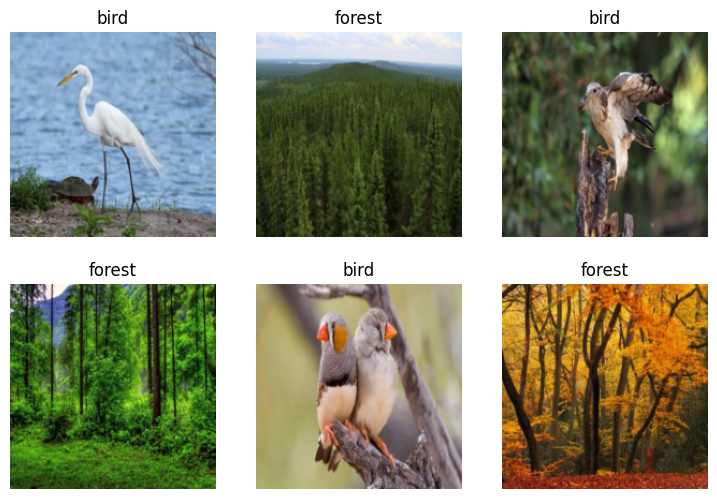

In [12]:
dls = DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path,bs=32)

dls.show_batch(max_n=6)

In [15]:
learn = vision_learner(dls,resnet18, metrics = error_rate)
learn.fine_tune(4)


epoch,train_loss,valid_loss,error_rate,time
0,0.621867,1.231431,0.297297,00:05


epoch,train_loss,valid_loss,error_rate,time
0,0.075181,0.325429,0.054054,00:01
1,0.037712,0.166268,0.054054,00:00
2,0.024618,0.106403,0.027027,00:00
3,0.018067,0.078932,0.027027,00:00


/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/mehrdad/miniforge3/envs/ml_env/lib/python3.11/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ im

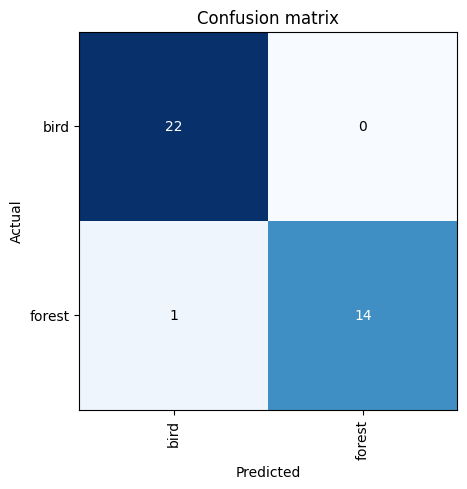

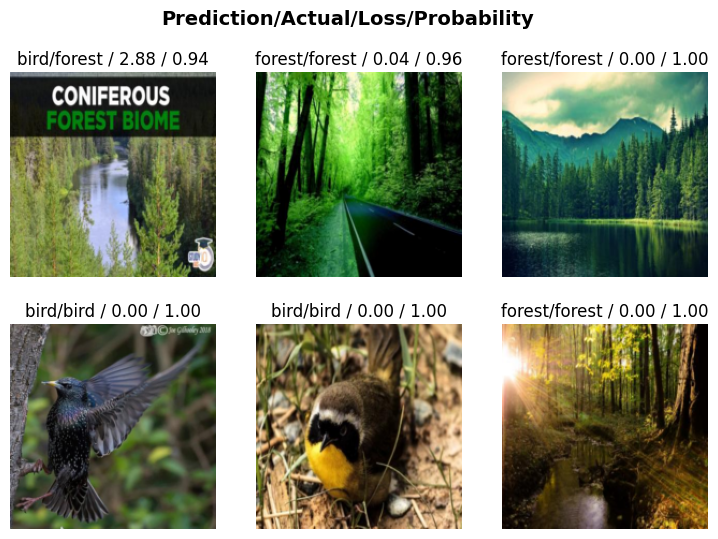

In [16]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(6)

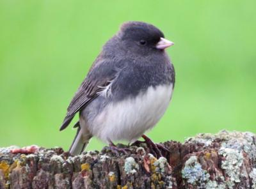

In [20]:
test_image = get_image_files(path/'bird')[0]
Image.open(test_image).to_thumb(256,256)

In [23]:
is_bird, _, probs = learn.predict(PILImage.create(test_image))
print(f"Prediction: {is_bird}")
print(f"Confidence: {probs.max():.2%}")

Prediction: bird
Confidence: 100.00%


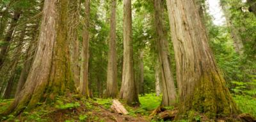

In [24]:
forest_test_img = get_image_files(path/'forest')[0]
Image.open(forest_test_img).to_thumb(256,256)

In [26]:
is_bird, _, probs = learn.predict(PILImage.create(forest_test_img))
print(f"Prediction: {is_bird}")
print(f"Confidence: {probs.max():.2%}")

Prediction: forest
Confidence: 100.00%


In [27]:
learn.export('bird_forest_model.pkl')